# **Data Analysis** / **Feature Engineering**

In [80]:
import pandas as pd

df = pd.read_csv("/Users/altair/Applications/aqi-predictor/Data_collection/data/raw/historical_dataset.csv")


In [81]:
print(df.head())
print(df.info())
print(df.describe())
print(df.shape)

         date  temperature_2m_max  temperature_2m_min  temperature_2m_mean  \
0  2024-01-01                18.3                 5.6                 11.3   
1  2024-01-02                16.1                 6.4                 10.4   
2  2024-01-03                16.0                 5.6                  9.3   
3  2024-01-04                16.1                 5.7                 10.2   
4  2024-01-05                16.1                 6.4                 10.3   

   precipitation_sum  wind_speed_10m_max      pm2_5       pm10  \
0                0.0                10.6  46.820833  70.829167   
1                0.0                10.4  47.225000  70.975000   
2                0.0                 6.0  59.083333  89.445833   
3                0.0                 7.1  60.116667  93.029167   
4                0.0                 7.3  63.808333  99.341667   

   carbon_monoxide  nitrogen_dioxide  sulphur_dioxide      ozone      us_aqi  
0      1771.583333         59.891667        13.175000  

In [82]:
print(df.isnull().sum())

date                   0
temperature_2m_max     0
temperature_2m_min     0
temperature_2m_mean    0
precipitation_sum      0
wind_speed_10m_max     0
pm2_5                  0
pm10                   0
carbon_monoxide        0
nitrogen_dioxide       0
sulphur_dioxide        0
ozone                  0
us_aqi                 0
dtype: int64


In [83]:
print(df.duplicated().sum())

df = df.drop_duplicates()

0


In [84]:
print(df.dtypes)

date                       str
temperature_2m_max     float64
temperature_2m_min     float64
temperature_2m_mean    float64
precipitation_sum      float64
wind_speed_10m_max     float64
pm2_5                  float64
pm10                   float64
carbon_monoxide        float64
nitrogen_dioxide       float64
sulphur_dioxide        float64
ozone                  float64
us_aqi                 float64
dtype: object


In [85]:
df["date"] = pd.to_datetime(df["date"])

In [86]:
print(df.dtypes)

date                   datetime64[us]
temperature_2m_max            float64
temperature_2m_min            float64
temperature_2m_mean           float64
precipitation_sum             float64
wind_speed_10m_max            float64
pm2_5                         float64
pm10                          float64
carbon_monoxide               float64
nitrogen_dioxide              float64
sulphur_dioxide               float64
ozone                         float64
us_aqi                        float64
dtype: object


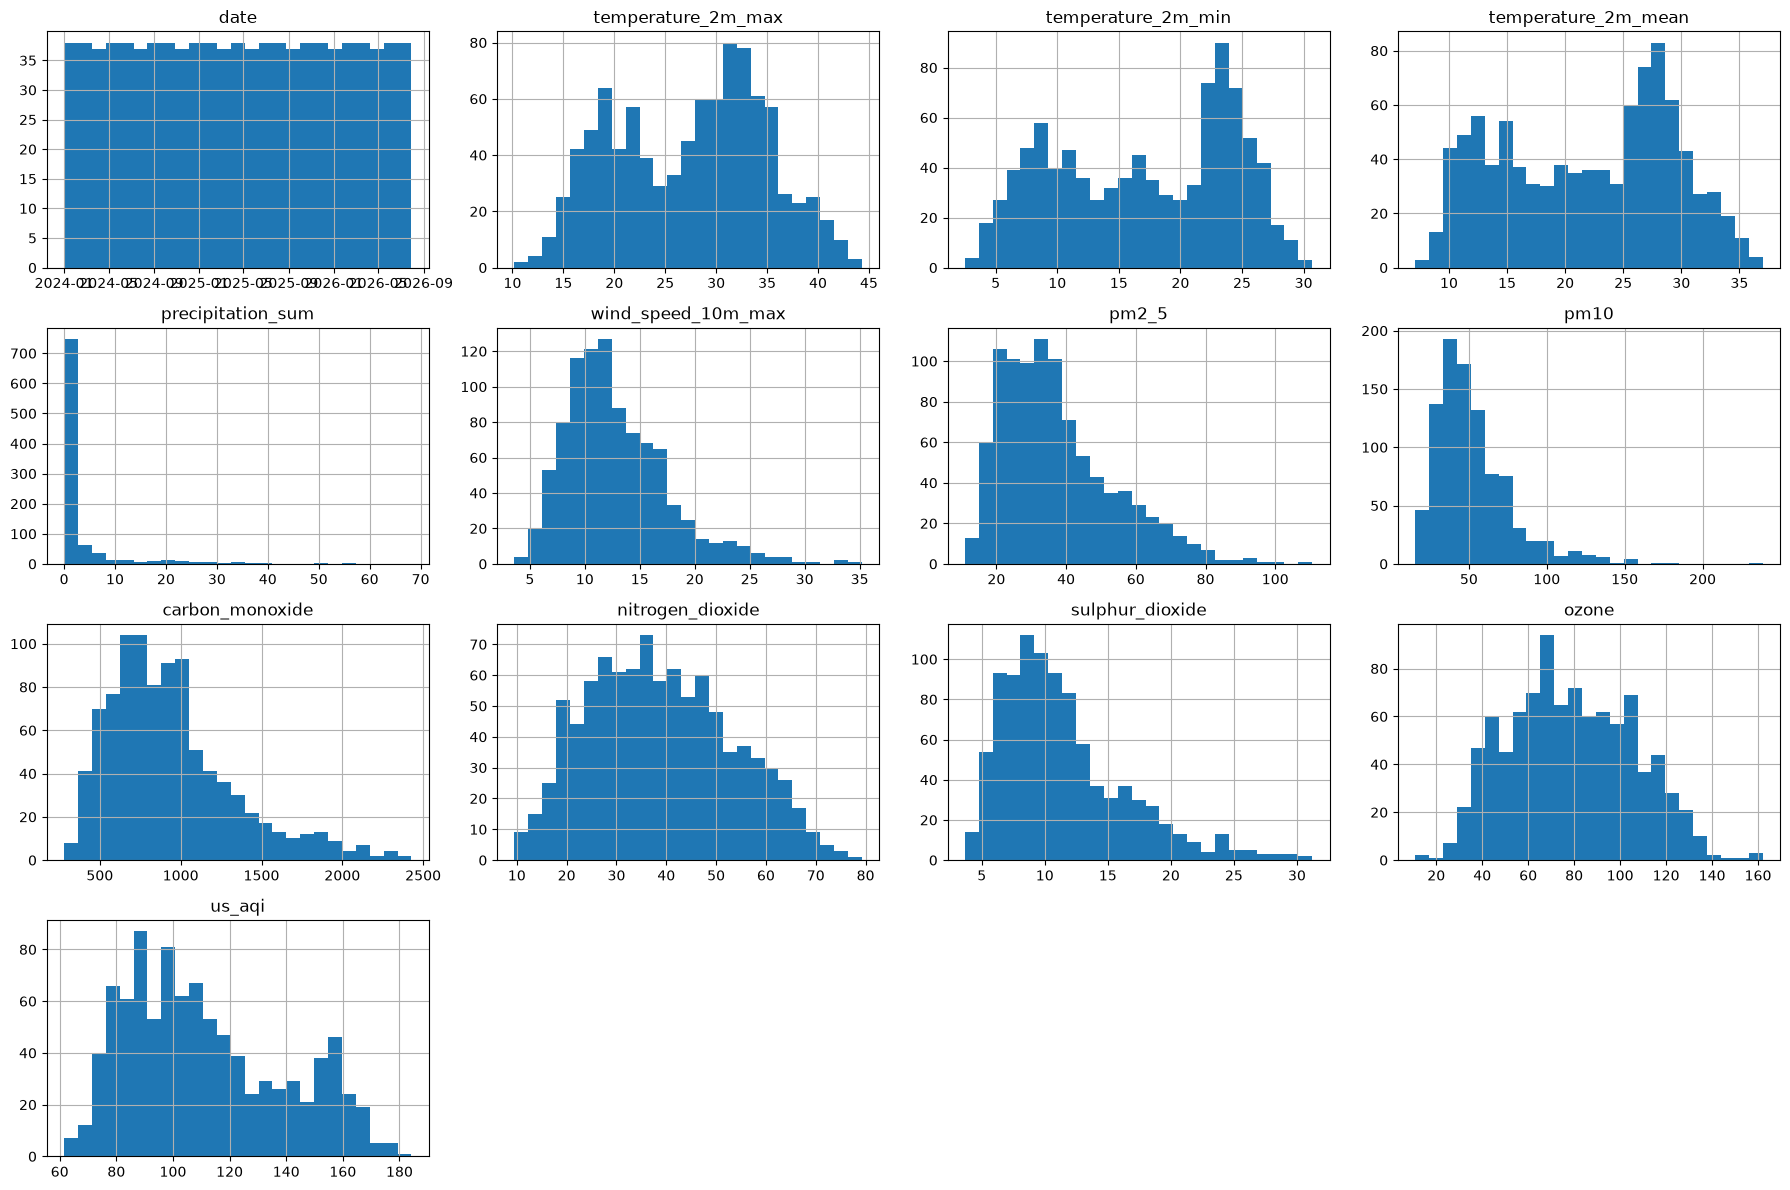

In [87]:
import matplotlib.pyplot as plt

df.hist(figsize=(18,12), bins=25)

plt.tight_layout()

plt.show()

## **Analysis**
### Skewed Features. some are positive but are valid because there are some conditions in which values can be high based on the weather condition. 
### in some features there are 2 peaks those are also valid because our data is of 2 years. 

In [88]:
print(df.skew(numeric_only=True))

temperature_2m_max    -0.093880
temperature_2m_min    -0.185833
temperature_2m_mean   -0.138190
precipitation_sum      3.921676
wind_speed_10m_max     1.084265
pm2_5                  1.011921
pm10                   1.850631
carbon_monoxide        1.107733
nitrogen_dioxide       0.257876
sulphur_dioxide        1.184205
ozone                  0.197793
us_aqi                 0.525047
dtype: float64


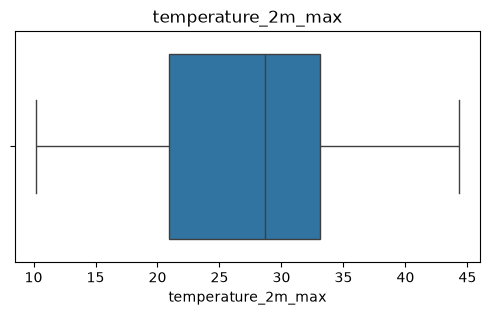

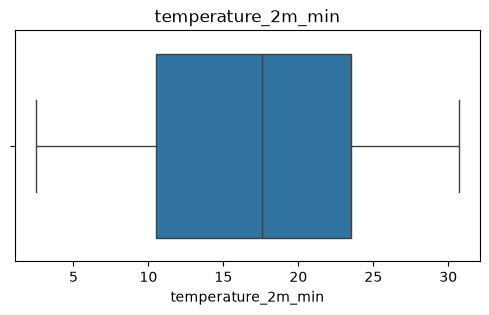

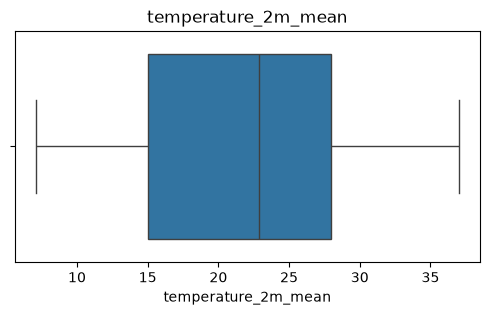

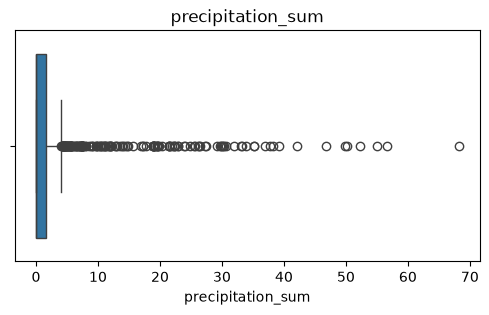

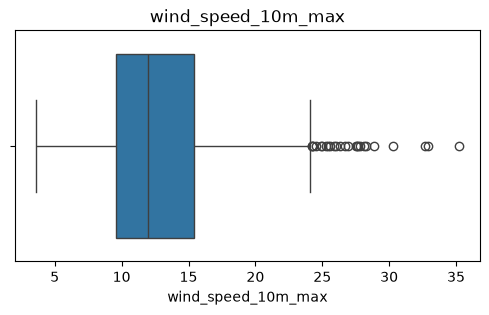

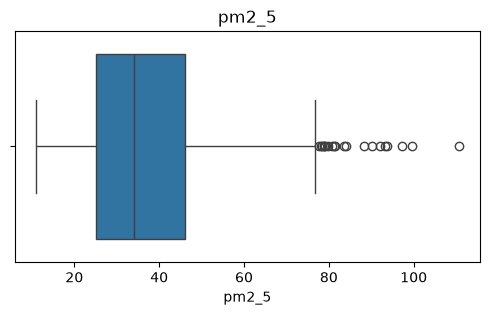

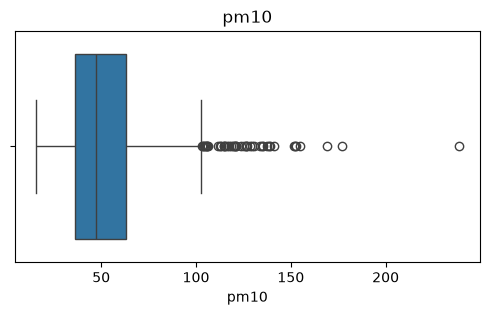

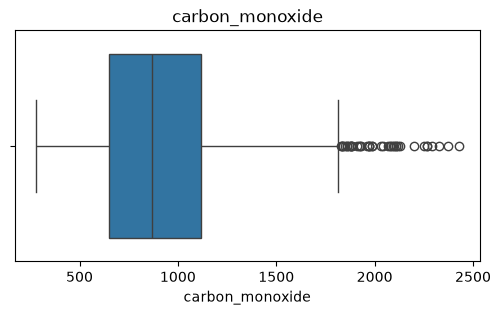

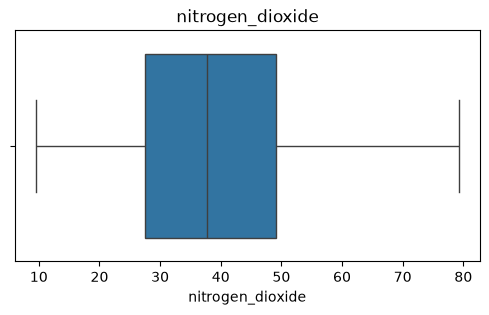

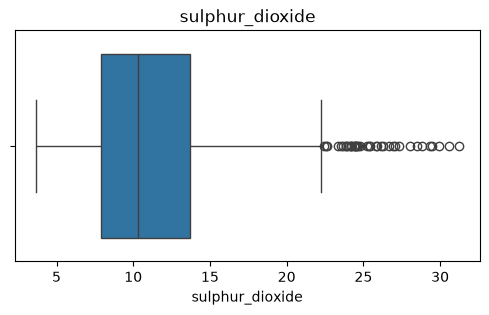

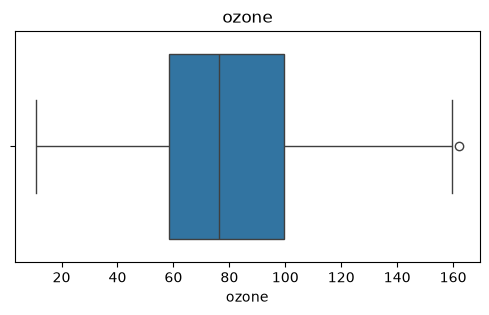

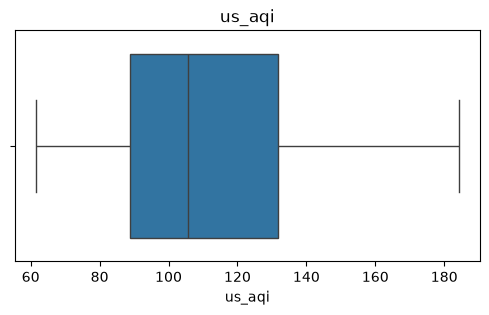

In [89]:
for column in df.select_dtypes(include="number"):

    plt.figure(figsize=(6,3))

    sns.boxplot(x=df[column])

    plt.title(column)

    plt.show()

## **Analysis**
### AQI naturally contains extreme pollution events, So no need to consider extreme values as outliers

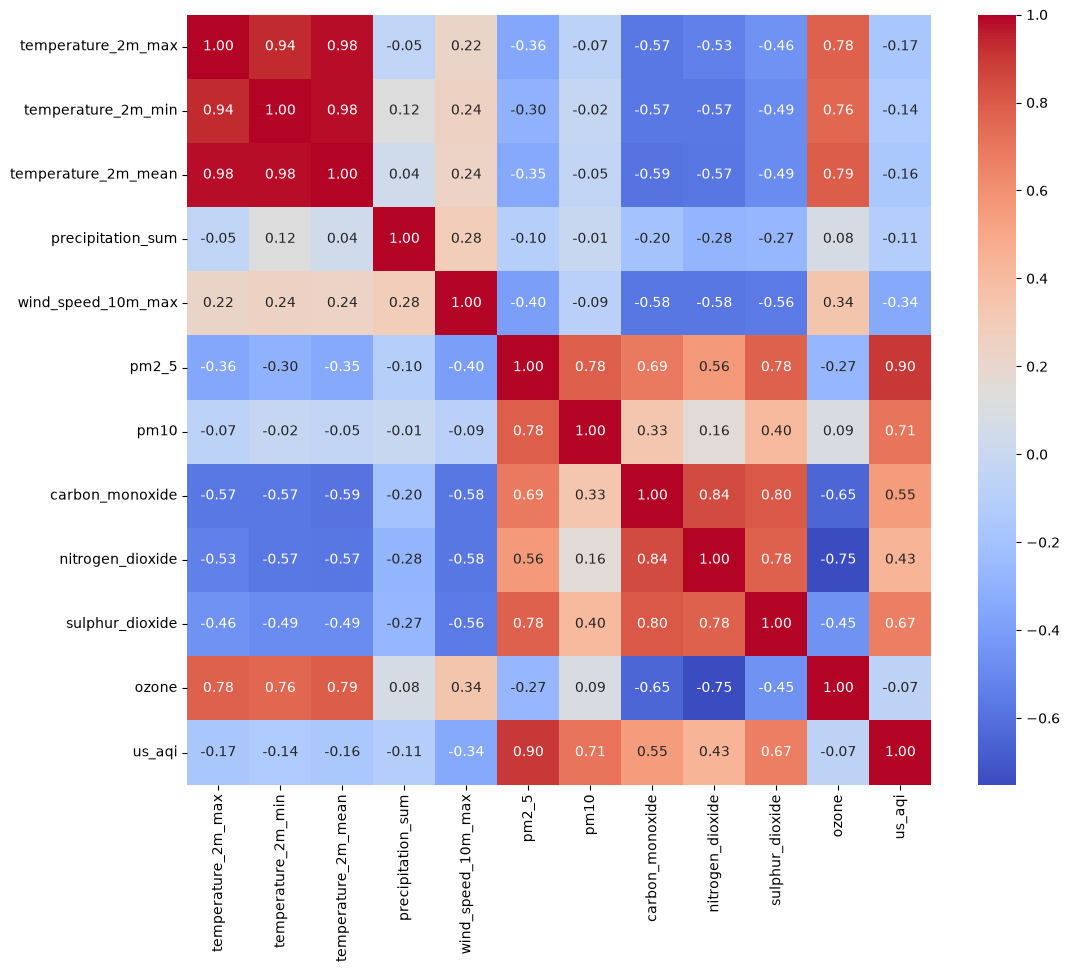

In [90]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.show()

## **Analysis**
### We can combine temperature_2m_max,temperature_2m_min,temperature_2m_mean because they are highly correlated. But combining them or not depends on the modeel we are using to train

In [91]:
corr = df.corr(numeric_only=True)["us_aqi"]

print(corr.sort_values())

wind_speed_10m_max    -0.341348
temperature_2m_max    -0.167092
temperature_2m_mean   -0.159558
temperature_2m_min    -0.139254
precipitation_sum     -0.113061
ozone                 -0.066178
nitrogen_dioxide       0.433073
carbon_monoxide        0.554377
sulphur_dioxide        0.670032
pm10                   0.709283
pm2_5                  0.897671
us_aqi                 1.000000
Name: us_aqi, dtype: float64


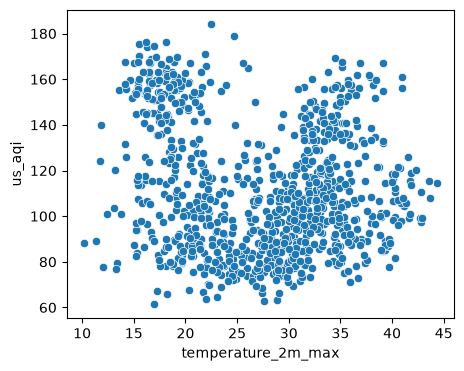

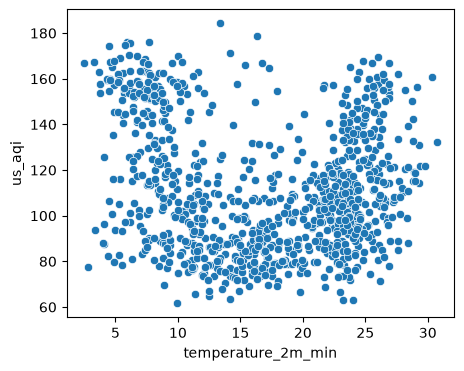

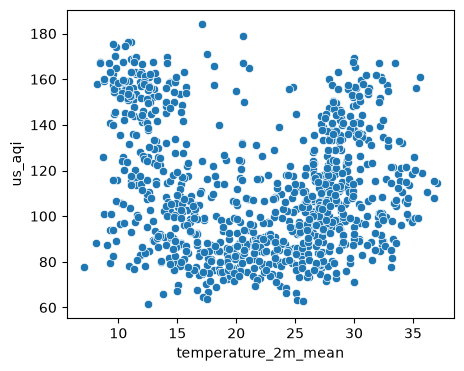

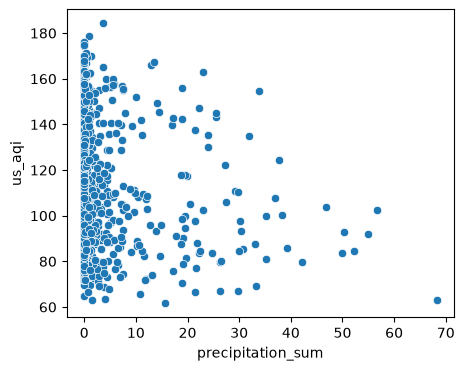

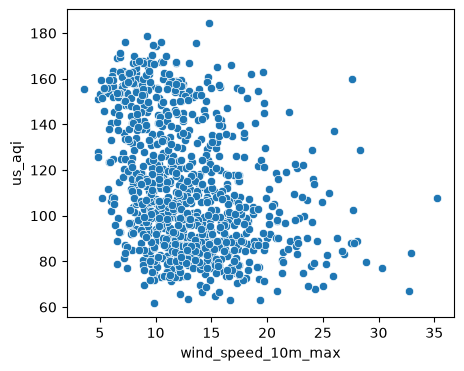

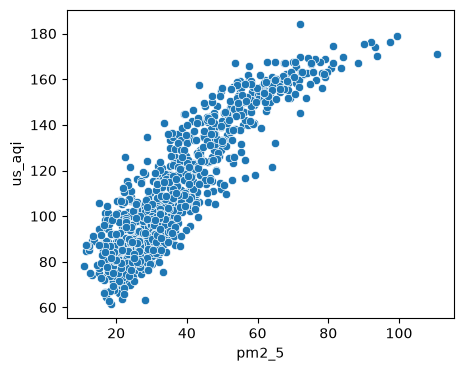

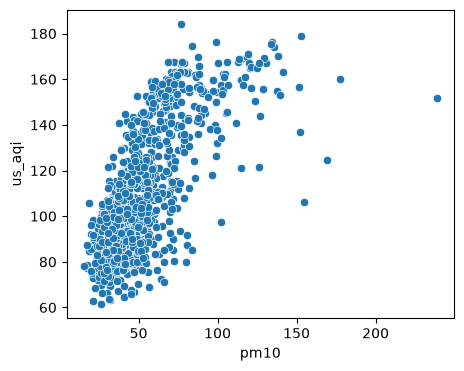

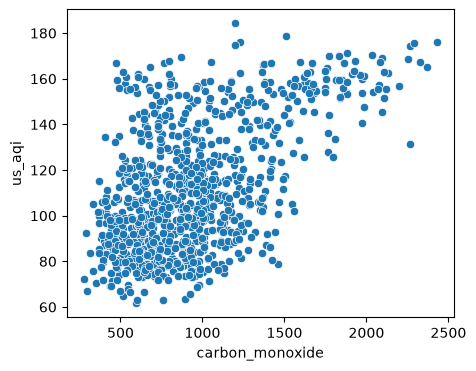

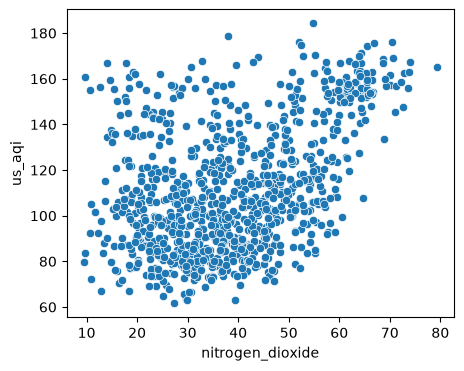

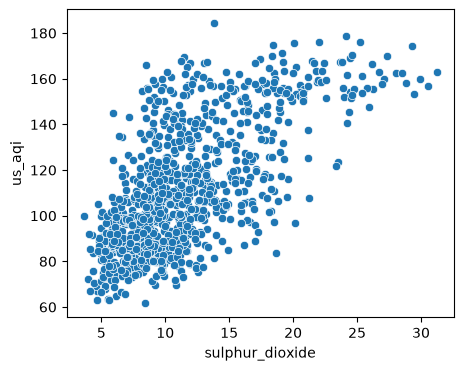

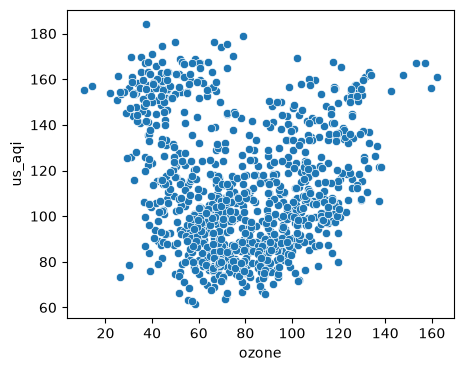

In [92]:
for column in df.columns:

    if column not in ["us_aqi","date"]:

        plt.figure(figsize=(5,4))

        sns.scatterplot(
            data=df,
            x=column,
            y="us_aqi"
        )

        plt.show()

## Analysis
### Only Pollutants have a linear relationship with AQI whereas weather featuree have weak relation or may be non linear relation which can be captured by deep learning or tree based models.

### Month feature importance for AQI,

AQI changes throughout the year because of changes in:
- Temperature
- Rainfall
- Wind speed
- Sunlight
- Traffic patterns
- Biomass burning
- Agricultural burning
- Industrial emissions

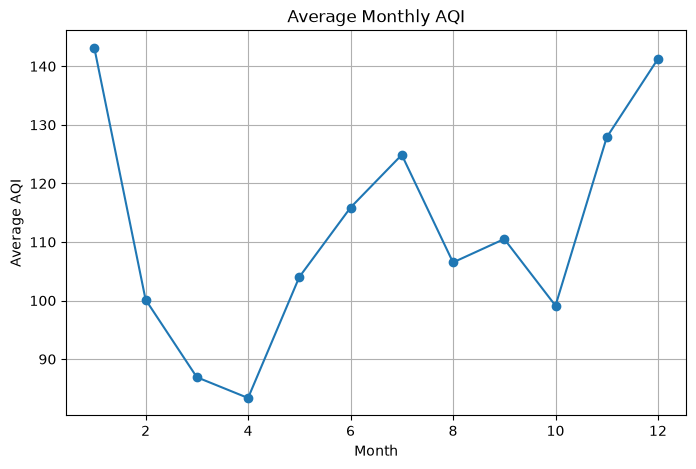

In [93]:
df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.month

monthly = (
    df.groupby("month")["us_aqi"]
      .mean()
      .reset_index()
)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(monthly["month"], monthly["us_aqi"], marker="o")
plt.xlabel("Month")
plt.ylabel("Average AQI")
plt.title("Average Monthly AQI")
plt.grid(True)
plt.show()

# Observations
## Winter (November–January)
### AQI is highest.
### This is common in many cities because:
### Cooler air can trap pollutants near the ground (temperature inversions).
### Lower wind speeds reduce dispersion.
### Additional emissions (heating, biomass burning, traffic) may contribute.
## Spring (March–April)
### AQI reaches its lowest levels.
### Likely due to better atmospheric mixing and fewer pollution episodes.
## Summer (June–July)
### AQI rises again.
### Hot weather and strong sunlight can increase ozone formation, and dry conditions can increase dust.
## Autumn (November)
### AQI increases sharply again, indicating a seasonal pollution pattern.

In [94]:
import numpy as np

df["month"] = pd.to_datetime(df["date"]).dt.month

df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

- 2π represents one complete circle (360°).
- month / 12 converts the month number into its fraction of the year.
- sin() gives the vertical coordinate.
- cos() gives the horizontal coordinate.

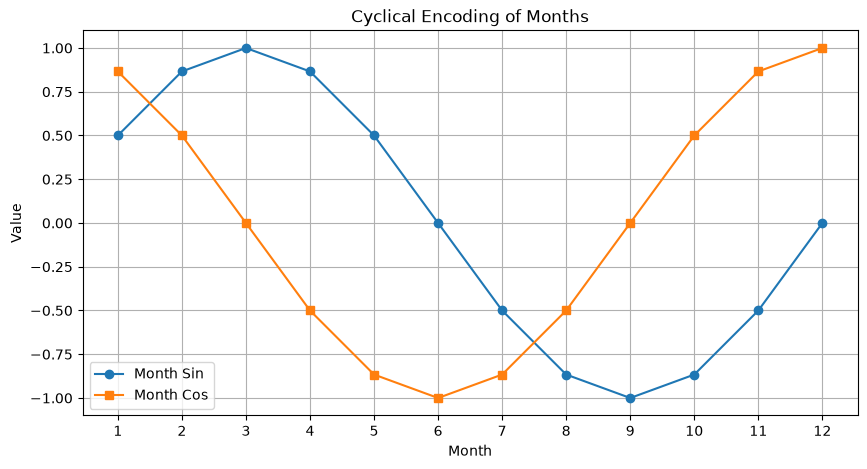

In [67]:
import matplotlib.pyplot as plt

month_features = (
    df[["month", "month_sin", "month_cos"]]
    .drop_duplicates()
    .sort_values("month")
)

plt.figure(figsize=(10,5))

plt.plot(
    month_features["month"],
    month_features["month_sin"],
    marker="o",
    label="Month Sin"
)

plt.plot(
    month_features["month"],
    month_features["month_cos"],
    marker="s",
    label="Month Cos"
)

plt.xticks(range(1,13))
plt.xlabel("Month")
plt.ylabel("Value")
plt.title("Cyclical Encoding of Months")
plt.grid(True)
plt.legend()

plt.show()

### Cyclic encoding

Cyclic encoding is a feature engineering technique used to represent cyclical (repeating) data such as:

Months (January → December → January)
Days of the week (Monday → Sunday → Monday)
Hours of the day (23:00 → 00:00)

It converts these values into sine and cosine values so that machine learning models understand their circular nature.

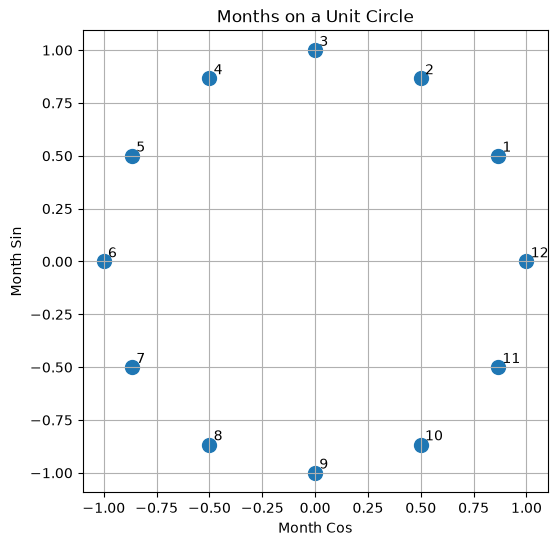

In [95]:
plt.figure(figsize=(6,6))

plt.scatter(
    month_features["month_cos"],
    month_features["month_sin"],
    s=100
)

for _, row in month_features.iterrows():
    plt.text(
        row["month_cos"] + 0.02,
        row["month_sin"] + 0.02,
        str(int(row["month"]))
    )

plt.xlabel("Month Cos")
plt.ylabel("Month Sin")
plt.title("Months on a Unit Circle")
plt.grid(True)
plt.axis("equal")

plt.show()

# Reason of sin and cos of month.
### AQI has a seasonal pattern, replacing the raw month feature with month_sin and month_cos is a common feature engineering technique. It helps models like neural networks and linear regression understand that December and January are adjacent in time.

In [96]:
df.head()

,date,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,us_aqi,month,month_sin,month_cos
0,2024-01-01,18.3,5.6,11.3,0.0,10.6,46.820833,70.829167,1771.583333,59.891667,13.175000,31.958333,144.083333,1,0.5,0.866025
1,2024-01-02,16.1,6.4,10.4,0.0,10.4,47.225000,70.975000,1620.625000,61.275000,18.125000,30.833333,125.916667,1,0.5,0.866025
2,2024-01-03,16.0,5.6,9.3,0.0,6.0,59.083333,89.445833,1971.583333,64.070833,24.200000,34.625000,140.833333,1,0.5,0.866025
3,2024-01-04,16.1,5.7,10.2,0.0,7.1,60.116667,93.029167,1870.708333,66.083333,17.779167,32.625000,153.541667,1,0.5,0.866025
4,2024-01-05,16.1,6.4,10.3,0.0,7.3,63.808333,99.341667,2042.666667,66.600000,24.437500,39.208333,154.208333,1,0.5,0.866025


In [97]:
df.tail()

,date,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,us_aqi,month,month_sin,month_cos
937,2026-07-26,32.1,24.9,28.0,1.4,8.0,28.216667,30.725000,756.291667,28.370833,8.229167,79.791667,92.625000,7,-0.5,-0.866025
938,2026-07-27,33.6,26.1,29.8,0.0,5.2,36.195833,37.633333,820.000000,46.825000,10.808333,76.666667,107.916667,7,-0.5,-0.866025
939,2026-07-28,34.3,26.2,29.9,1.9,12.1,34.141667,37.241667,974.875000,27.608333,10.975000,105.416667,109.000000,7,-0.5,-0.866025
940,2026-07-29,30.9,23.4,27.2,6.0,12.0,36.937500,41.341667,963.083333,29.020833,9.783333,107.541667,110.041667,7,-0.5,-0.866025
941,2026-07-30,32.2,24.8,28.5,0.9,12.3,44.020833,47.700000,836.750000,36.066667,10.025000,95.916667,124.291667,7,-0.5,-0.866025


In [98]:
df.rename(columns={"us_aqi": "AQI"}, inplace=True)

In [99]:
print(df.columns)

Index(['date', 'temperature_2m_max', 'temperature_2m_min',
       'temperature_2m_mean', 'precipitation_sum', 'wind_speed_10m_max',
       'pm2_5', 'pm10', 'carbon_monoxide', 'nitrogen_dioxide',
       'sulphur_dioxide', 'ozone', 'AQI', 'month', 'month_sin', 'month_cos'],
      dtype='str')


In [100]:
df.to_csv("/Users/altair/Applications/aqi-predictor/Data_collection/data/raw/historical_dataset.csv", index=False)

In [101]:
df.head()

,date,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,AQI,month,month_sin,month_cos
0,2024-01-01,18.3,5.6,11.3,0.0,10.6,46.820833,70.829167,1771.583333,59.891667,13.175000,31.958333,144.083333,1,0.5,0.866025
1,2024-01-02,16.1,6.4,10.4,0.0,10.4,47.225000,70.975000,1620.625000,61.275000,18.125000,30.833333,125.916667,1,0.5,0.866025
2,2024-01-03,16.0,5.6,9.3,0.0,6.0,59.083333,89.445833,1971.583333,64.070833,24.200000,34.625000,140.833333,1,0.5,0.866025
3,2024-01-04,16.1,5.7,10.2,0.0,7.1,60.116667,93.029167,1870.708333,66.083333,17.779167,32.625000,153.541667,1,0.5,0.866025
4,2024-01-05,16.1,6.4,10.3,0.0,7.3,63.808333,99.341667,2042.666667,66.600000,24.437500,39.208333,154.208333,1,0.5,0.866025
